# Setup del notebook

In [1]:
import glob, sys, os
hits = glob.glob('/kaggle/input/**/config.py', recursive=True)
if not hits:
    print('NO encontre config.py bajo /kaggle/input. Adjunta el Output de la Parte I.')
    for root, _, files in os.walk('/kaggle/input'):
        for f in files: print('  ', os.path.join(root, f))
    raise SystemExit('Falta la salida de la Parte I.')

src = os.path.dirname(hits[0])
sys.path.insert(0, src)
import config, preprocessing, cleaning
print('Artefactos en:', config.ARTIFACTS)

clean = cleaning.clean_subset()

Artefactos en: /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/artifacts
REPORTE DE LIMPIEZA -- Boise, ID

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 3
  - negocios sin atributos: 264
  - negocios sin price_range: 1,366
  - negocios sin horario: 412
  - outliers review_count (>p99=325), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 3,471
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 2,589
  - outliers review_count (>p99=486), marcados no eliminados: 439

[Check-ins]
  - total check-ins contados: 154,145

[Tips]
  - tips duplicados eliminados: 0

Filas tras limpieza:
  business : 2,941
  reviews  : 101,955
  users    : 43,934
  checkins : 2,474
  tips     : 11,436


# Matriz de features

Clusterizamos negocios. Cada negocio se representa con dos bloques. Primero, 7 features continuas: stars (rating), log_reviews y log_checkins (uso logaritmo porque son power-law osea sin log, un negocio con 1810 reseñas aplastaría a todo lo demás), price_range (imputado con la mediana, porque su 46% de faltantes es estructural, no error), n_categories, n_days_open e is_open. Segundo, one-hot de las 25 categorías más comunes. esta es la señal dominante, porque los negocios se agrupan sobre todo por lo que son (restaurante vs taller vs spa).

Estandarizo todo a z-score porque K-Means mide distancias y necesita escalas comparables, y excluyo lat/long a propósito, para que los clusters salgan por tipo de negocio y no por barrio (podemos añadir geografía después si queremos). Y recuerda: esta misma matriz es la que el PCA y SVD de la Parte VI van a reutilizar.

In [2]:
%%writefile features.py
import numpy as np
import pandas as pd
from collections import Counter


def _behavioral(reviews):
    ref = reviews['date'].max()
    agg = reviews.groupby('business_id').agg(
        rating_std=('stars', 'std'),
        first_review=('date', 'min'),
        avg_review_length=('text_len', 'mean'),
    ).reset_index()
    agg['rating_std'] = agg['rating_std'].fillna(0.0)
    agg['business_age_years'] = (ref - agg['first_review']).dt.days / 365.25
    return agg[['business_id', 'rating_std', 'business_age_years', 'avg_review_length']]


def build_business_features(clean, top_categories=18, cat_weight=1.0):
    biz = clean['business'].copy().reset_index(drop=True)

    chk = clean['checkins']
    if 'n_checkins' in chk.columns:
        biz = biz.merge(chk[['business_id', 'n_checkins']], on='business_id', how='left')
    if 'n_checkins' not in biz.columns:
        biz['n_checkins'] = 0
    biz['n_checkins'] = biz['n_checkins'].fillna(0)

    biz = biz.merge(_behavioral(clean['reviews']), on='business_id', how='left')
    for col in ('rating_std', 'business_age_years', 'avg_review_length'):
        biz[col] = biz[col].fillna(0.0)

    pr_med = biz['price_range'].median()
    biz['price_range_imp'] = biz['price_range'].fillna(pr_med)

    cont = pd.DataFrame({
        'stars':         biz['stars'].astype(float),
        'log_reviews':   np.log1p(biz['review_count'].astype(float)),
        'price_range':   biz['price_range_imp'].astype(float),
        'n_categories':  biz['n_categories'].astype(float),
        'n_days_open':   biz['n_days_open'].astype(float),
        'log_checkins':  np.log1p(biz['n_checkins'].astype(float)),
        'is_open':       biz['is_open'].astype(float),
        'rating_std':    biz['rating_std'].astype(float),
        'business_age':  biz['business_age_years'].astype(float),
        'avg_rev_len':   biz['avg_review_length'].astype(float),
    })

    cat_counts = Counter()
    for lst in biz['categories_list']:
        cat_counts.update(lst)
    top = [c for c, _ in cat_counts.most_common(top_categories)]
    cat_mat = pd.DataFrame(
        {f'cat::{c}': biz['categories_list'].apply(lambda l, c=c: 1.0 if c in l else 0.0)
         for c in top}
    )

    feat = pd.concat([cont, cat_mat], axis=1)
    names = list(feat.columns)

    X = feat.to_numpy(dtype=float)
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1.0
    Xz = (X - mu) / sd

    if cat_weight != 1.0:
        cat_cols = [i for i, n in enumerate(names) if n.startswith('cat::')]
        Xz[:, cat_cols] *= cat_weight

    return Xz, names, biz['business_id'].to_numpy(), biz

Writing features.py


In [3]:
import importlib, features
importlib.reload(features)

X, feat_names, biz_ids, biz_df = features.build_business_features(clean, top_categories=18)
print(f'Matriz de features: {X.shape[0]} negocios x {X.shape[1]} features\n')
for n in feat_names:
    print('  ', n)

Matriz de features: 2941 negocios x 28 features

   stars
   log_reviews
   price_range
   n_categories
   n_days_open
   log_checkins
   is_open
   rating_std
   business_age
   avg_rev_len
   cat::Restaurants
   cat::Food
   cat::Shopping
   cat::Home Services
   cat::Local Services
   cat::Beauty & Spas
   cat::Automotive
   cat::Nightlife
   cat::Health & Medical
   cat::Bars
   cat::Event Planning & Services
   cat::Active Life
   cat::Coffee & Tea
   cat::Sandwiches
   cat::Hotels & Travel
   cat::American (Traditional)
   cat::Burgers
   cat::Fast Food


# El camino de K-means++

In [4]:
%%writefile kmeans.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


def _dists_sq(X, C):
    xx = (X * X).sum(1)[:, None]
    cc = (C * C).sum(1)[None, :]
    return np.maximum(xx + cc - 2 * X @ C.T, 0)


def _init_pp(X, k, rng):
    n = X.shape[0]
    first = int(rng.integers(n))
    centroids = [X[first]]
    d2 = ((X - X[first]) ** 2).sum(1)
    for _ in range(1, k):
        s = d2.sum()
        probs = d2 / s if s > 0 else np.full(n, 1.0 / n)
        idx = int(rng.choice(n, p=probs))
        centroids.append(X[idx])
        d2 = np.minimum(d2, ((X - X[idx]) ** 2).sum(1))
    return np.array(centroids)


def kmeans_pp(X, k, max_iter=100, tol=1e-4, seed=0, n_init=5):
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_init):
        C = _init_pp(X, k, rng)
        for _ in range(max_iter):
            labels = _dists_sq(X, C).argmin(1)
            newC = np.array([X[labels == j].mean(0) if np.any(labels == j) else C[j]
                             for j in range(k)])
            if np.sqrt(((newC - C) ** 2).sum()) < tol:
                C = newC
                break
            C = newC
        labels = _dists_sq(X, C).argmin(1)
        inertia = _dists_sq(X, C)[np.arange(len(X)), labels].sum()
        if best is None or inertia < best[2]:
            best = (labels, C, float(inertia))
    return best


def _pairwise_D(X):
    xx = (X * X).sum(1)
    return np.sqrt(np.maximum(xx[:, None] + xx[None, :] - 2 * X @ X.T, 0))


def silhouette_score(X, labels, D=None):
    if D is None:
        D = _pairwise_D(X)
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    if len(uniq) < 2:
        return 0.0
    sil = np.zeros(len(labels))
    for c in uniq:
        idx = np.where(labels == c)[0]
        if len(idx) <= 1:
            continue
        others = [np.where(labels == o)[0] for o in uniq if o != c]
        for i in idx:
            a = D[i, idx[idx != i]].mean()
            b = min(D[i, o].mean() for o in others)
            sil[i] = (b - a) / max(a, b) if max(a, b) > 0 else 0.0
    return float(sil.mean())


def choose_k(X, k_min=2, k_max=10, seed=0):
    D = _pairwise_D(X)
    ks, inertias, sils, results = [], [], [], {}
    for k in range(k_min, k_max + 1):
        labels, C, inertia = kmeans_pp(X, k, seed=seed)
        s = silhouette_score(X, labels, D=D)
        ks.append(k); inertias.append(inertia); sils.append(s)
        results[k] = (labels, C, inertia, s)
        print(f'  k={k}: inercia={inertia:10.1f}  silueta={s:.4f}')
    return ks, inertias, sils, results


def plot_k_selection(ks, inertias, sils):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(ks, inertias, 'o-', color='#378ADD')
    ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia (SSE intra-cluster)')
    ax[0].set_title('Metodo del codo')
    ax[1].plot(ks, sils, 'o-', color='#D85A30')
    ax[1].set_xlabel('k'); ax[1].set_ylabel('Coeficiente de silueta')
    best = ks[int(np.argmax(sils))]
    ax[1].axvline(best, ls='--', color='gray', alpha=0.6)
    ax[1].set_title(f'Silueta por k (maxima en k={best})')
    plt.tight_layout(); plt.show()


def characterize_clusters(labels, biz_df):
    df = biz_df.copy(); df['cluster'] = labels
    rows = []
    for c in sorted(set(labels)):
        sub = df[df['cluster'] == c]
        cats = Counter()
        for lst in sub['categories_list']:
            cats.update(lst)
        rows.append({
            'cluster': c, 'n': len(sub),
            'stars': round(sub['stars'].mean(), 2),
            'reviews_med': int(sub['review_count'].median()),
            'price': round(sub['price_range_imp'].mean(), 2),
            'rating_std': round(sub['rating_std'].mean(), 2),
            'age_anios': round(sub['business_age_years'].mean(), 1),
            'pct_abierto': round(sub['is_open'].mean(), 2),
            'top_categorias': ', '.join(c for c, _ in cats.most_common(4)),
        })
    return pd.DataFrame(rows)

Writing kmeans.py


Matriz (comportamental): 2941 x 28  (10 features activas, categorias en peso 0)

  k=2: inercia=   24932.2  silueta=0.1527
  k=3: inercia=   21789.7  silueta=0.1590
  k=4: inercia=   19536.9  silueta=0.1741
  k=5: inercia=   18000.8  silueta=0.1831
  k=6: inercia=   16839.4  silueta=0.1720
  k=7: inercia=   15776.8  silueta=0.1740
  k=8: inercia=   15087.2  silueta=0.1725
  k=9: inercia=   14560.1  silueta=0.1589
  k=10: inercia=   14022.3  silueta=0.1784


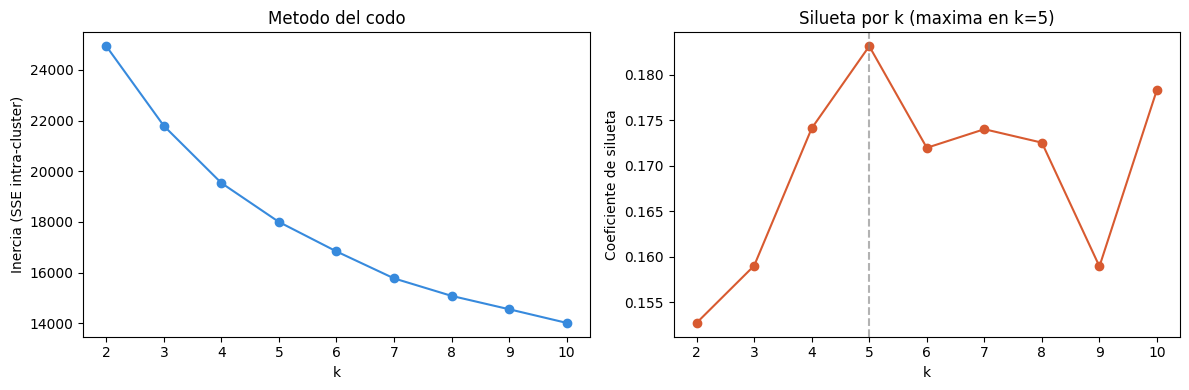

In [5]:
import importlib, features, kmeans
importlib.reload(features); importlib.reload(kmeans)

# clustering 100% comportamental (categorias solo describiran despues)
X, feat_names, biz_ids, biz_df = features.build_business_features(
    clean, top_categories=18, cat_weight=0.0)
print(f'Matriz (comportamental): {X.shape[0]} x {X.shape[1]}  '
      f'(10 features activas, categorias en peso 0)\n')

ks, inertias, sils, results = kmeans.choose_k(X, k_min=2, k_max=10)
kmeans.plot_k_selection(ks, inertias, sils)

In [6]:
# k=5: maximo de silueta y coincide con el codo
labels, C, inertia5, sil5 = results[5]
print(f'k=5  |  silueta={sil5:.4f}  |  inercia={inertia5:.1f}  |  '
      f'tamanos={[int((labels==j).sum()) for j in range(5)]}\n')

profile = kmeans.characterize_clusters(labels, biz_df)
profile

k=5  |  silueta=0.1831  |  inercia=18000.8  |  tamanos=[600, 940, 683, 331, 387]



,cluster,n,stars,reviews_med,price,rating_std,age_anios,pct_abierto,top_categorias
0,0,600,4.82,9,1.97,0.46,5.8,0.97,"Shopping, Home Services, Beauty & Spas, Food"
1,1,940,3.28,10,1.98,1.65,7.0,1.00,"Shopping, Home Services, Local Services, Autom..."
2,2,683,3.65,55,1.64,1.34,10.1,1.00,"Restaurants, Food, Nightlife, Bars"
3,3,331,3.58,16,1.79,1.33,9.1,0.00,"Restaurants, Food, Shopping, Nightlife"
4,4,387,3.30,9,1.82,1.36,9.1,0.68,"Restaurants, Food, Shopping, Active Life"


Cluster 0 — "Las joyas de nicho" (n=600). Rating altísimo (4.82★, el mayor), pocas reseñas (mediana 9), polarización bajísima (0.46 — todos los aman por igual), los más jóvenes (5.8 años) y casi todos abiertos (97%). Son spas, salones, servicios a domicilio y tiendas pequeñas: negocios boutique que quien los visita adora, pero de bajo volumen. La joya escondida del manual.

Cluster 1 — "Los servicios divisivos" (n=940, el más grande). Rating bajo (3.28), pocas reseñas, pero la polarización más alta de todas (1.65), y el 100% abiertos. Talleres, servicios locales, automotriz, retail cotidiano: el grueso de la economía de servicios, donde las experiencias dividen fuerte (el mecánico que para unos es excelente y para otros un desastre). Amor-odio puro.

Cluster 2 — "Los veteranos populares" (n=683). Mediana de 55 reseñas — 5 a 6 veces más que cualquier otro cluster, los más antiguos (10.1 años), 100% abiertos, restaurantes/bares/nightlife. Son los pesos pesados consolidados de la escena gastronómica. Y acá hay una conexión preciosa con tu Parte II: estos son los mismos negocios que salieron como authorities en HITS (Fork, Bittercreek, Goldy's...). Dos métodos distintos, mismo grupo de élite. Eso es oro para el reporte.

Cluster 3 — "El cementerio" (n=331, el más chico). Su rasgo definitorio: 0% abiertos — todos cerrados. Restaurantes/comida/nightlife, ~9 años de antigüedad. K-Means aisló a los que no sobrevivieron. Es un segmento melancólico pero analíticamente jugoso, y engancha directo con la ética de la Parte VII (survivorship bias: ¿qué distingue a los que cerraron?).

Cluster 4 — "Los que luchan" (n=387). Antiguos (9.1 años), rating bajo (3.30), pocas reseñas, y un 68% abiertos (un tercio ya cerró). Restaurantes y comercios de comida/actividad de gama media en aprietos. El segmento en riesgo, a mitad de camino entre los veteranos y el cementerio.

# DBSCAN

In [7]:
%%writefile dbscan.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _pairwise_D(X):
    xx = (X * X).sum(1)
    return np.sqrt(np.maximum(xx[:, None] + xx[None, :] - 2 * X @ X.T, 0))


def k_distance(X, k, D=None):
    if D is None:
        D = _pairwise_D(X)
    kd = np.sort(D, axis=1)[:, k]
    return np.sort(kd)


def plot_k_distance(kd, k):
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(kd)), kd, color='#378ADD')
    plt.xlabel('Negocios (ordenados por distancia)')
    plt.ylabel(f'Distancia al vecino #{k}')
    plt.title(f'k-distance plot (k={k}) — el "codo" sugiere eps')
    plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def dbscan(X, eps, min_pts, D=None):
    n = len(X)
    if D is None:
        D = _pairwise_D(X)
    neighbors = [np.where(D[i] <= eps)[0] for i in range(n)]
    labels = np.full(n, -1, dtype=int)
    visited = np.zeros(n, dtype=bool)
    cid = 0
    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True
        if len(neighbors[i]) < min_pts:
            continue
        labels[i] = cid
        seeds = list(neighbors[i])
        j = 0
        while j < len(seeds):
            q = seeds[j]; j += 1
            if not visited[q]:
                visited[q] = True
                if len(neighbors[q]) >= min_pts:
                    seeds.extend(neighbors[q].tolist())
            if labels[q] == -1:
                labels[q] = cid
        cid += 1
    return labels


def dbscan_summary(labels):
    n_noise = int((labels == -1).sum())
    clusters = sorted(c for c in set(labels.tolist()) if c != -1)
    rows = [{'cluster': c, 'n': int((labels == c).sum())} for c in clusters]
    rows.append({'cluster': 'outliers (-1)', 'n': n_noise})
    print(f'{len(clusters)} clusters + {n_noise} outliers '
          f'({100 * n_noise / len(labels):.1f}% del total)')
    return pd.DataFrame(rows)

Writing dbscan.py


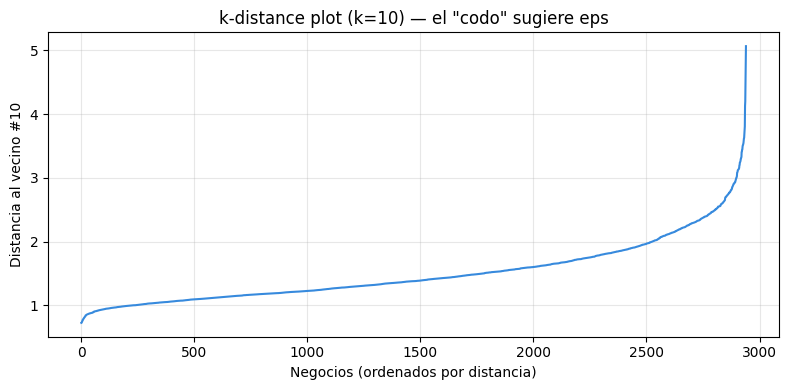

Distancia al vecino #10:  min=0.722  mediana=1.378  p90=2.193  max=5.067


In [8]:
import importlib, dbscan
import numpy as np   
importlib.reload(dbscan)

MIN_PTS = 10
D = dbscan._pairwise_D(X)
kd = dbscan.k_distance(X, k=MIN_PTS, D=D)
dbscan.plot_k_distance(kd, k=MIN_PTS)
print(f'Distancia al vecino #{MIN_PTS}:  min={kd.min():.3f}  '
      f'mediana={np.median(kd):.3f}  p90={np.quantile(kd,0.9):.3f}  max={kd.max():.3f}')

In [9]:
import importlib, dbscan, kmeans
importlib.reload(dbscan); importlib.reload(kmeans)

EPS, MIN_PTS = 2.0, 10
db_labels = dbscan.dbscan(X, eps=EPS, min_pts=MIN_PTS, D=D)   # reutiliza la D de arriba
print(f'DBSCAN(eps={EPS}, min_pts={MIN_PTS}):')
display(dbscan.dbscan_summary(db_labels))

# caracterizar incluyendo el grupo -1 (outliers) -> storytelling
print('\nPerfil de los grupos DBSCAN (cluster -1 = outliers):')
kmeans.characterize_clusters(db_labels, biz_df)

DBSCAN(eps=2.0, min_pts=10):
7 clusters + 153 outliers (5.2% del total)


,cluster,n
0,0,1911
1,1,95
2,2,417
3,3,36
4,4,285
5,5,34
6,6,10
7,outliers (-1),153



Perfil de los grupos DBSCAN (cluster -1 = outliers):


,cluster,n,stars,reviews_med,price,rating_std,age_anios,pct_abierto,top_categorias
0,-1,153,3.34,10,2.5,1.01,8.3,0.6,"Shopping, Restaurants, Local Services, Food"
1,0,1911,3.82,12,2.0,1.25,7.4,1.0,"Restaurants, Shopping, Home Services, Food"
2,1,95,3.81,17,1.0,1.19,9.0,0.0,"Restaurants, Food, Coffee & Tea, Mexican"
3,2,417,3.48,23,1.0,1.37,9.0,1.0,"Restaurants, Food, Fast Food, Burgers"
4,3,36,3.49,9,1.0,1.30,10.4,0.0,"Restaurants, Food, Coffee & Tea, American (Tra..."
5,4,285,3.55,12,2.0,1.32,9.4,0.0,"Restaurants, Food, Shopping, Nightlife"
6,5,34,3.75,16,3.0,1.55,9.6,1.0,"Shopping, Fashion, Local Services, Beauty & Spas"
7,6,10,3.00,11,4.0,1.83,8.0,1.0,"Shopping, Home & Garden, Local Services, Home ..."


DBSCAN encontró un cluster dominante (el 0, con 1,911 negocios = 65% del total) más varios grupos chicos y 153 outliers (5.2%). Donde K-Means repartió el continuo en 5 segmentos parejos, DBSCAN dice la verdad geométrica: la mayoría de los negocios forman una sola masa densa conectada, con algunos bolsones más densos alrededor y una cola de rarezas. Ni uno está "mal" — responden preguntas distintas (K-Means segmenta para estrategia; DBSCAN revela densidad y caza anomalías).


Coincidencia entre métodos. 

Varios clusters chicos de DBSCAN (el 1, 2, 3) tienen pct_abierto=0.0 — son negocios cerrados, igual que el "cementerio" (cluster 3) de K-Means. Que dos algoritmos independientes aíslen a los cerrados confirma que el estatus abierto/cerrado es una frontera real en los datos.


Los outliers son insight nuevo. 

Los 153 outliers tienen el precio promedio más alto (2.5 vs ~2.0) y estatus mixto (60% abiertos) — son los negocios atípicos (caros, inusuales) que K-Means jamás te marca porque está obligado a meter todo en algún cluster. Esos 153 son justo el material de la Parte VII (ética): ¿son spam, errores, o nichos legítimos? Y fíjate en el cluster 6 (n=10, precio 4.0, el tope): un bolsón diminuto de negocios premium.

# Comparativa K-Means++ vs DBSCAN

In [10]:
%%writefile compare.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def pca_2d(X):
    Xc = X - X.mean(0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    P = Xc @ Vt[:2].T
    var = (S[:2] ** 2) / (S ** 2).sum()
    return P, var


def compare_metrics(X, labels_km, labels_db, silhouette_fn):
    rows = []
    s_km = silhouette_fn(X, np.asarray(labels_km))
    rows.append({'metodo': 'K-Means++', 'n_clusters': len(set(np.asarray(labels_km).tolist())),
                 'outliers': 0, 'silueta': round(s_km, 4)})
    db = np.asarray(labels_db)
    mask = db != -1
    n_db = len(set(db.tolist()) - {-1})
    s_db = silhouette_fn(X[mask], db[mask]) if n_db >= 2 else float('nan')
    rows.append({'metodo': 'DBSCAN', 'n_clusters': n_db,
                 'outliers': int((~mask).sum()),
                 'silueta': round(s_db, 4) if n_db >= 2 else None})
    return pd.DataFrame(rows)


def plot_clusters_2d(P, labels_km, labels_db, var):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
    km = np.asarray(labels_km)
    ax[0].scatter(P[:, 0], P[:, 1], c=km, cmap='tab10', s=6, alpha=0.6)
    ax[0].set_title(f'K-Means++  (k={len(set(km.tolist()))})')

    db = np.asarray(labels_db)
    out = db == -1
    ax[1].scatter(P[out, 0], P[out, 1], c='lightgray', s=6, alpha=0.5, label='outliers')
    ax[1].scatter(P[~out, 0], P[~out, 1], c=db[~out], cmap='tab10', s=6, alpha=0.6)
    ax[1].set_title(f'DBSCAN  ({len(set(db.tolist()) - {-1})} clusters + {int(out.sum())} outliers)')
    ax[1].legend(loc='upper right', fontsize=8)

    for a in ax:
        a.set_xlabel(f'PC1 ({var[0] * 100:.0f}% var)')
        a.set_ylabel(f'PC2 ({var[1] * 100:.0f}% var)')
    plt.tight_layout(); plt.show()

Writing compare.py


Comparativa K-Means++ vs DBSCAN:


,metodo,n_clusters,outliers,silueta
0,K-Means++,5,0,0.1831
1,DBSCAN,7,153,0.0803


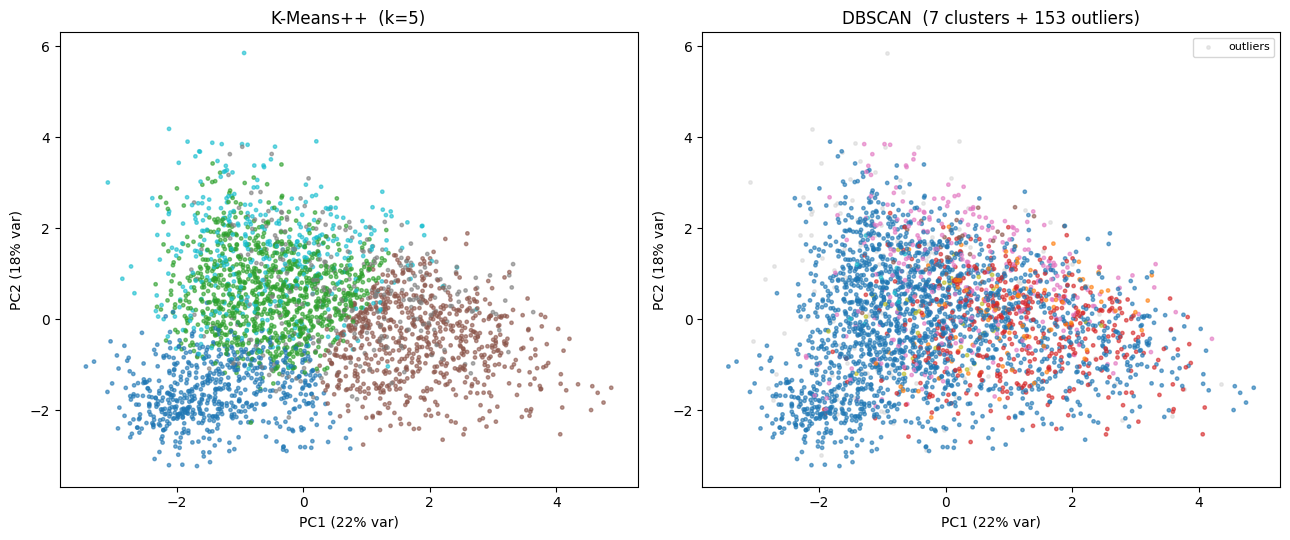

In [11]:
import importlib, compare, kmeans
importlib.reload(compare); importlib.reload(kmeans)

metrics = compare.compare_metrics(X, labels, db_labels, kmeans.silhouette_score)
print('Comparativa K-Means++ vs DBSCAN:')
display(metrics)

P, var = compare.pca_2d(X)
compare.plot_clusters_2d(P, labels, db_labels, var)